In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_excel("/content/drive/MyDrive/Mu_files/Telco_customer_churn.xlsx")
data.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [3]:
data=data.drop(['CustomerID','Churn Reason','Country','State','Count','City','Latitude','Longitude','Lat Long','Zip Code','Churn Score','Churn Label'],axis=1)
data.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,CLTV
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,3239
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,2701
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1,5372
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,5003
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1,5340


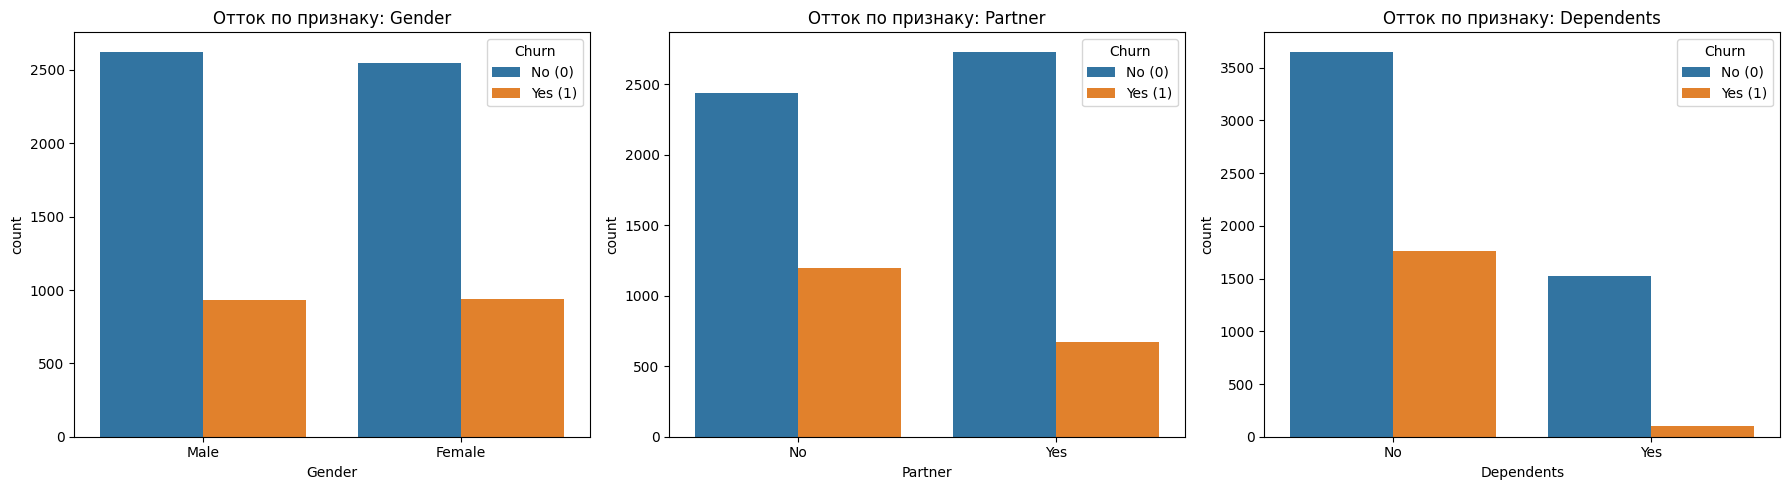

In [12]:
features = ['Gender', 'Partner', 'Dependents']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for feature, ax in zip(features, axes):
    sns.countplot(data=data, x=feature, hue='Churn Value', ax=ax)
    ax.set_title(f'Отток по признаку: {feature}')
    ax.legend(title='Churn', labels=['No (0)', 'Yes (1)'], loc='upper right')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Тип контракта и отток')

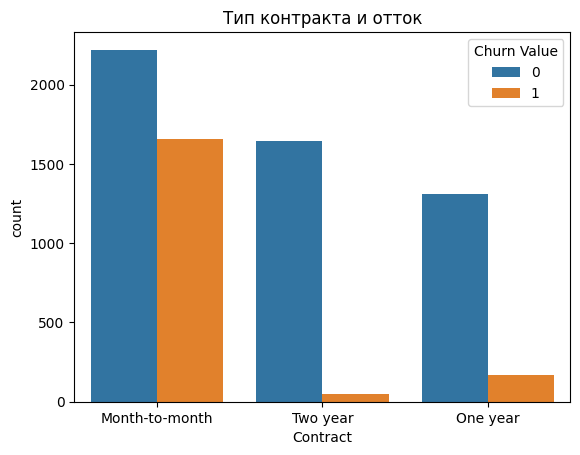

In [5]:
sns.countplot(data=data, x='Contract', hue='Churn Value')
plt.title('Тип контракта и отток')

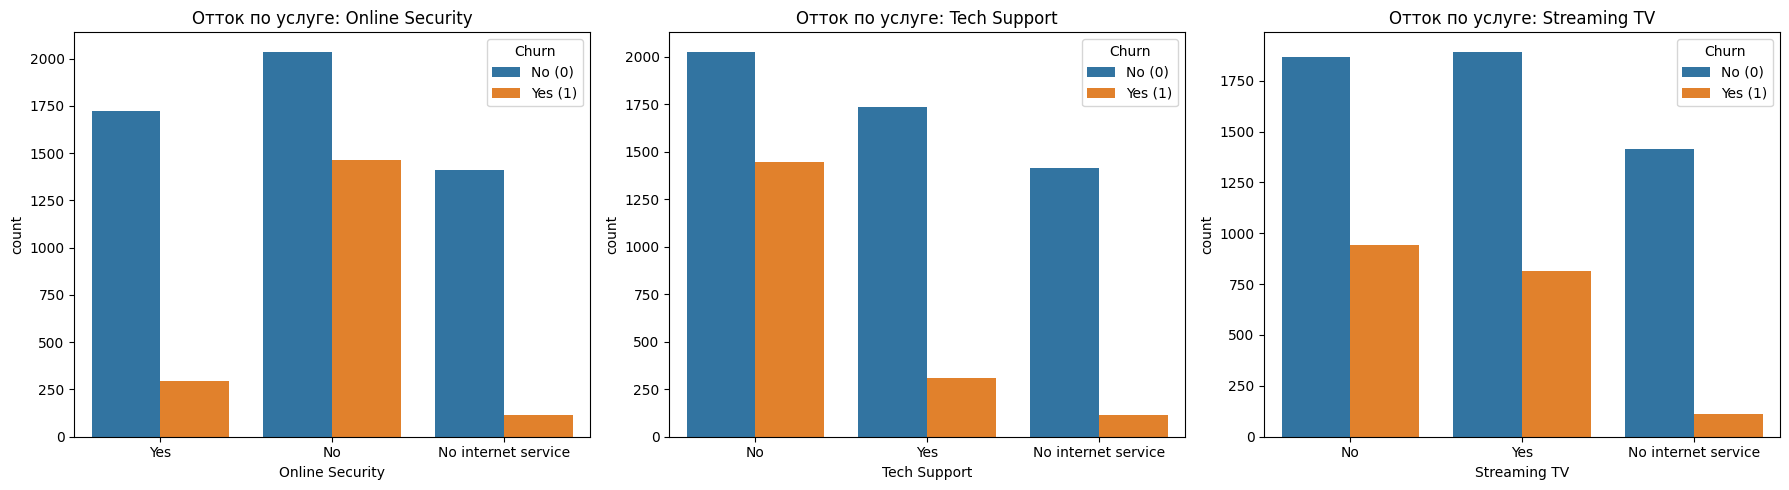

In [11]:
services = ['Online Security', 'Tech Support', 'Streaming TV']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for service, ax in zip(services, axes):
    sns.countplot(data=data, x=service, hue='Churn Value', ax=ax)
    ax.set_title(f'Отток по услуге: {service}')
    ax.legend(title='Churn', labels=['No (0)', 'Yes (1)'])
plt.tight_layout()
plt.show()

In [16]:
data['Total Charges'] = pd.to_numeric(data['Total Charges'], errors='coerce')
data=data.dropna()

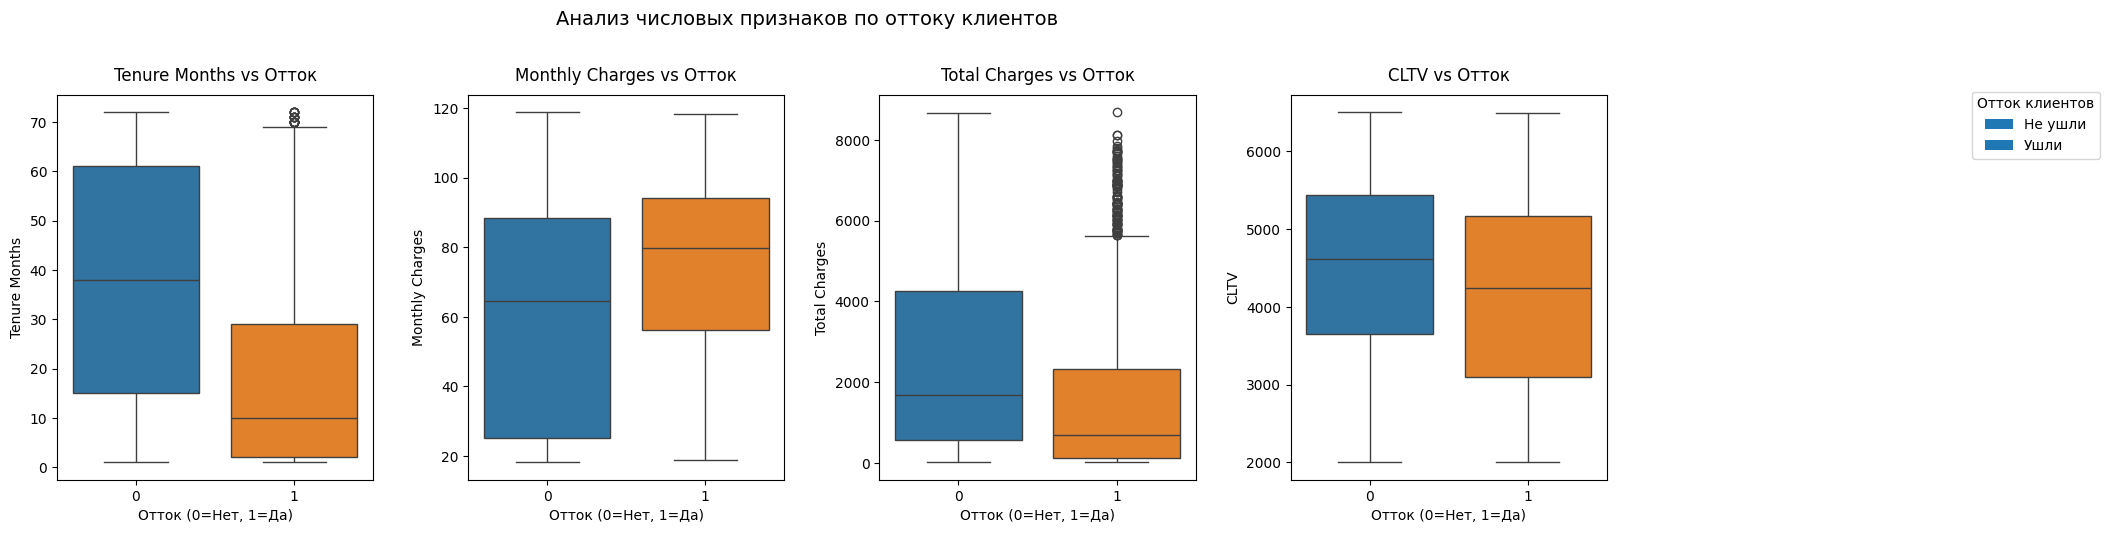

In [31]:
num_features = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
plt.subplots_adjust(wspace=0.3)
for i, col in enumerate(num_features):
    sns.boxplot(x='Churn Value', y=col, data=data,
                ax=axes[i], hue='Churn Value',dodge=False)

    axes[i].set_title(f'{col} vs Отток', pad=10, fontsize=12)
    axes[i].set_xlabel('Отток (0=Нет, 1=Да)', fontsize=10)
    axes[i].set_ylabel(col, fontsize=10)
    axes[i].get_legend().remove()

handles = [plt.Rectangle((0,0), 1, 1, label=v)
           for k, v in {0: 'Не ушли', 1: 'Ушли'}.items()]
fig.legend(handles=handles, title='Отток клиентов',
           loc='upper right', bbox_to_anchor=(1.15, 0.9))
fig.suptitle('Анализ числовых признаков по оттоку клиентов', y=1.05, fontsize=14)
plt.show()